In [6]:
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


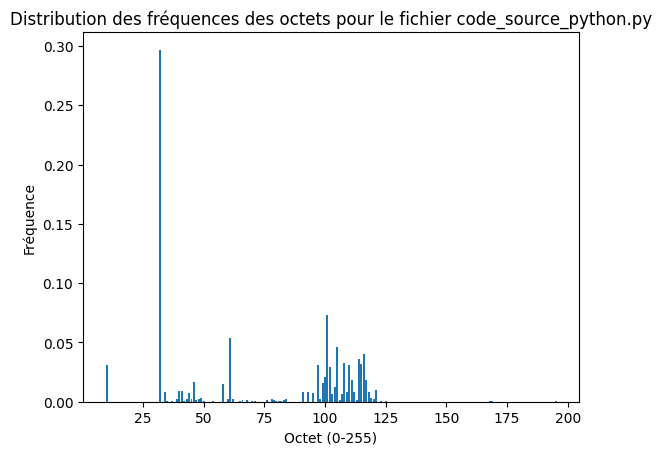

=== Analyse de code_source_python.py ===
  taille_octets: 3844
  entropie: 4.368
  economie_max_h0: 45.41
  longueur_plage_max: 78
  longueur_plage_moy: 1.33
  couverture_motifs_4grams: 100.0


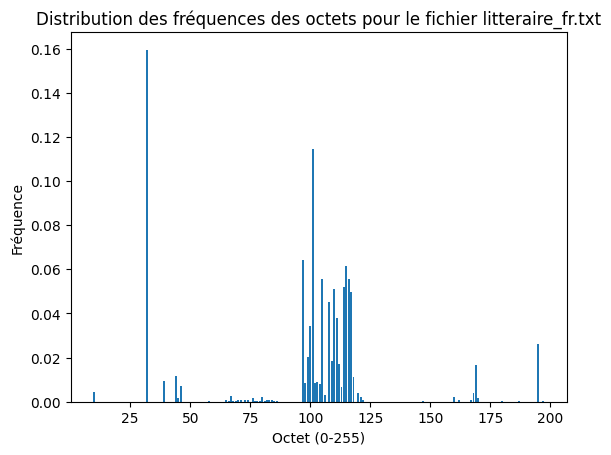

=== Analyse de litteraire_fr.txt ===
  taille_octets: 5092
  entropie: 4.422
  economie_max_h0: 44.73
  longueur_plage_max: 2
  longueur_plage_moy: 1.02
  couverture_motifs_4grams: 100.0


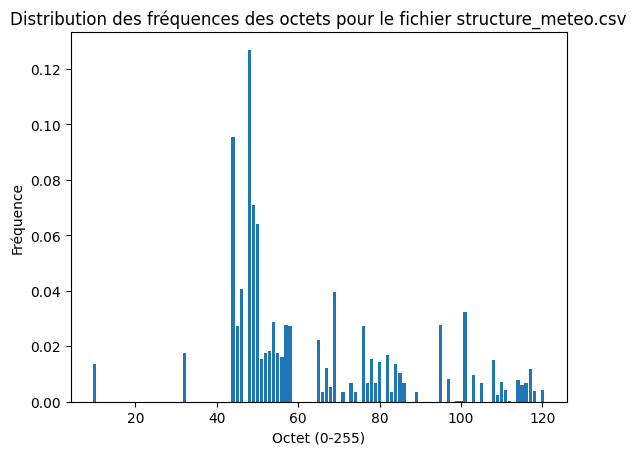

=== Analyse de structure_meteo.csv ===
  taille_octets: 26515
  entropie: 4.969
  economie_max_h0: 37.89
  longueur_plage_max: 3
  longueur_plage_moy: 1.06
  couverture_motifs_4grams: 100.0


In [ ]:
def analyser_fichier(chemin_fichier: str) -> dict:
    with open(chemin_fichier, 'rb') as f:
        donnees = f.read()
    
    n_octets = len(donnees)
    if n_octets == 0:
        return {}

    # 1. Entropie du fichier (H0)
    comptage_octets = Counter(donnees)
    probs = np.array(list(comptage_octets.values())) / n_octets
    h0 = -np.sum(probs * np.log2(probs))

    # 2. Analyse des plages consécutives (RLE)
    plages = []
    longueur_courante = 1
    for i in range(1, n_octets):
        if donnees[i] == donnees[i-1]:
            longueur_courante += 1
        else:
            plages.append(longueur_courante)
            longueur_courante = 1
    plages.append(longueur_courante)

    # 3. Taux de couverture des motifs de longueur >= 4 (LZ77)
    motifs_4 = Counter([donnees[i:i+4] for i in range(n_octets - 3)])
    octets_repetes = sum(c * 4 for motif, c in motifs_4.items() if c > 1)
    taux_couverture_lz = min(100.0, (octets_repetes / n_octets) * 100)

    # 4. Limites théoriques de compression (en octets)
    taille_min_h0 = (h0 * n_octets) / 8

    # 5. Distribution des fréquences des caractères (plot)
    frequences = {octet: count / n_octets for octet, count in comptage_octets.items()}
    plt.bar(frequences.keys(), frequences.values())
    plt.title(f"Distribution des fréquences des octets pour le fichier {chemin_fichier}")
    plt.xlabel("Octet (0-255)")
    plt.ylabel("Fréquence")
    plt.show()

    return {
        "taille_octets": n_octets,
        "entropie": round(h0, 3),
        "economie_max_h0": round((1 - taille_min_h0 / n_octets) * 100, 2),
        "longueur_plage_max": max(plages),
        "longueur_plage_moy": round(np.mean(plages), 2),
        "couverture_motifs_4grams": round(taux_couverture_lz, 2)
    }

fichiers = ["code_source_python.py", "litteraire_fr.txt", "structure_meteo.csv"]
for f in fichiers:
    res = analyser_fichier(f)
    print(f"=== Analyse de {f} ===")
    for k, v in res.items():
        print(f"  {k}: {v}")

In [ ]:
# plot the distribution of the character frequencies for each file

for f in fichiers:
    res = analyser_fichier(f)
    